In [34]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_theme(style="whitegrid")
from sklearn.metrics import precision_recall_curve, confusion_matrix, recall_score, precision_score, roc_auc_score



In [35]:
df = pd.read_csv("../data/predicted/train_predicted_xgboost_ONLINE_regularization_scale_pos_2860_added_fraud_count_maxdepth4_estimators150_added_added_behaviour_smoothening2000_regularixzation_nomccrisk_bestparams.csv", parse_dates=["date"])


In [36]:
mapping = {True:"Yes", False:"No"}
df["predicted_class"] = df["predicted_prob"]>0.5
df["predicted_class"] = df["predicted_class"].map(mapping)

In [37]:
incorrect_classified = df[df["target"]!=df["predicted_class"]]
correct_classified = df[df["target"]==df["predicted_class"]]
print("Incorrect:", incorrect_classified.shape[0])
print("Correct:", correct_classified.shape[0])

Incorrect: 17476
Correct: 592182


In [38]:

threshold = 0.5
high_confidence_fn_threshold = 0.1

y_true = (df["target"].astype(str).str.lower().str.strip() == "yes").astype(int)

correct_mask = ((y_true == 1) & (df["predicted_prob"] >= threshold)) | ((y_true == 0) & (df["predicted_prob"] < threshold))
incorrect_mask = ~correct_mask

correct_classified = df[correct_mask]
incorrect_classified = df[incorrect_mask]

incorrect_with_high_probability_fp = incorrect_classified[incorrect_classified["predicted_prob"] >= threshold]
incorrect_with_high_probability_fn = incorrect_classified[incorrect_classified["predicted_prob"] < high_confidence_fn_threshold]
correct_classified_tn = correct_classified[correct_classified["predicted_prob"] < threshold]
correct_classified_tp = correct_classified[correct_classified["predicted_prob"] >= threshold]

print("False negatives (p < 0.1):", incorrect_with_high_probability_fn.shape[0])
print("False positives (p >= 0.5):", incorrect_with_high_probability_fp.shape[0])

False negatives (p < 0.1): 385
False positives (p >= 0.5): 14197


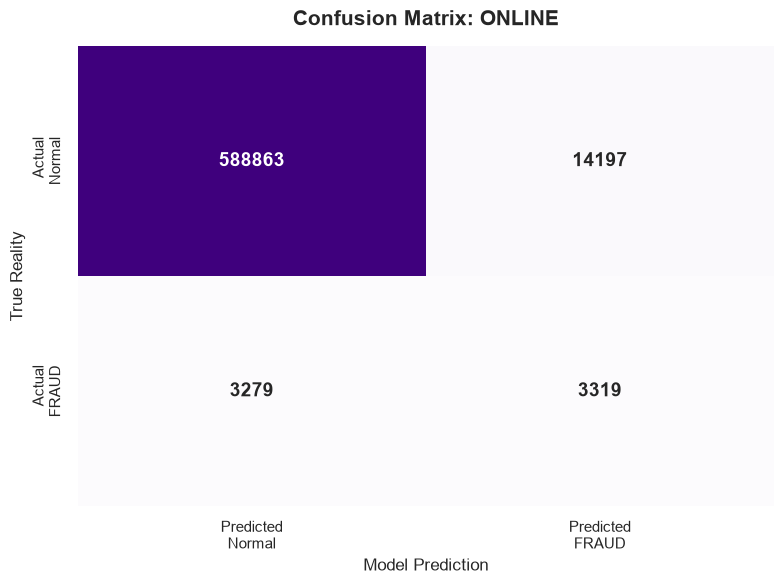

In [39]:


df_cm = df.copy()
if df_cm["target"].dtype != "object":
    df_cm["target"] = df_cm["target"].map({1: "Yes", 0: "No"})
else:
    df_cm["target"] = df_cm["target"]

labels = ["No", "Yes"]
cm_online = confusion_matrix(df_cm["target"], df_cm["predicted_class"], labels=labels)

plt.figure(figsize=(8, 6))

x_tick_labels = ["Predicted\nNormal", "Predicted\nFRAUD"]
y_tick_labels = ["Actual\nNormal", "Actual\nFRAUD"]

sns.heatmap(
    cm_online, annot=True, fmt="d", cmap="Purples", cbar=False,
    annot_kws={"size": 14, "weight": "bold"},
    xticklabels=x_tick_labels, yticklabels=y_tick_labels
)
plt.title("Confusion Matrix: ONLINE", fontsize=15, fontweight="bold", pad=15)
plt.xlabel("Model Prediction", fontsize=12)
plt.ylabel("True Reality", fontsize=12)

plt.tight_layout()
plt.show()


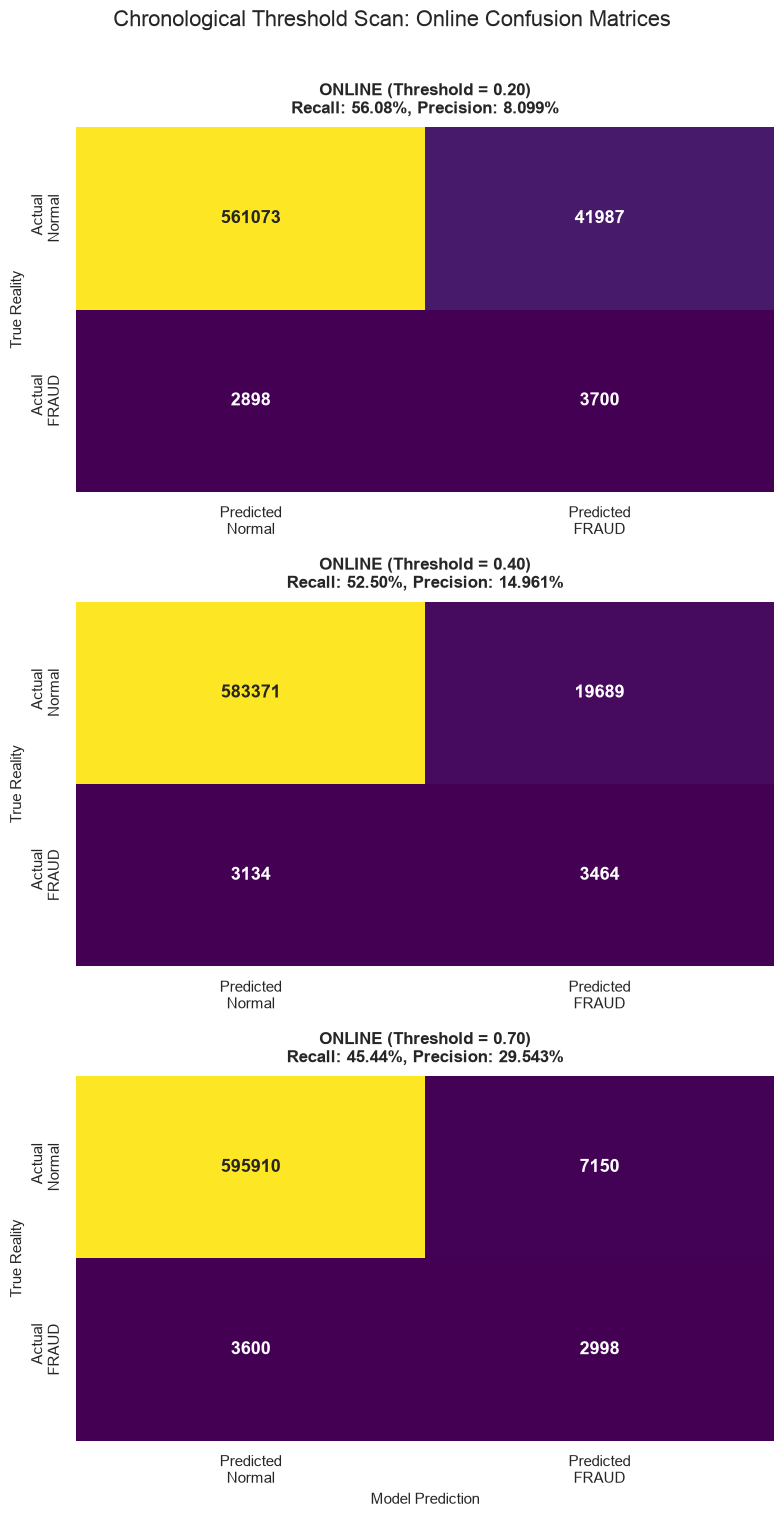

In [40]:


thresholds = [0.2, 0.4, 0.7]

df_cm = df.copy()

if df_cm["target"].dtype != "object":
    df_cm["target"] = df_cm["target"].map({1: "Yes", 0: "No"})
else:
    df_cm["target"] = df_cm["target"]

n_rows = len(thresholds)
sns.set_theme(style="white") 

fig, axes = plt.subplots(n_rows, 1, figsize=(8, 5 * n_rows))

if n_rows == 1:
    axes = np.array([axes])

labels = ["No", "Yes"]
x_tick_labels = ["Predicted\nNormal", "Predicted\nFRAUD"]
y_tick_labels = ["Actual\nNormal", "Actual\nFRAUD"]

for i, t in enumerate(thresholds):
    preds_bin = (df_cm["predicted_prob"] >= t).astype(int).map({1: "Yes", 0: "No"})
    cm = confusion_matrix(df_cm["target"], preds_bin, labels=labels)
    
    y_true = (df_cm["target"] == "Yes").astype(int)
    y_pred = (df_cm["predicted_prob"] >= t).astype(int)
    rec = recall_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)

    sns.heatmap(
        cm, annot=True, fmt="d", cmap="viridis", cbar=False,
        annot_kws={"size": 13, "weight": "bold"},
        xticklabels=x_tick_labels, yticklabels=y_tick_labels, ax=axes[i]
    )
    axes[i].set_title(
        f"ONLINE (Threshold = {t:.2f})\nRecall: {rec:.2%}, Precision: {prec:.3%}", 
        fontsize=12, fontweight="bold", pad=10
    )
    axes[i].set_ylabel("True Reality", fontsize=11)
    if i == n_rows - 1:
         axes[i].set_xlabel("Model Prediction", fontsize=11)

plt.suptitle("Chronological Threshold Scan: Online Confusion Matrices", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

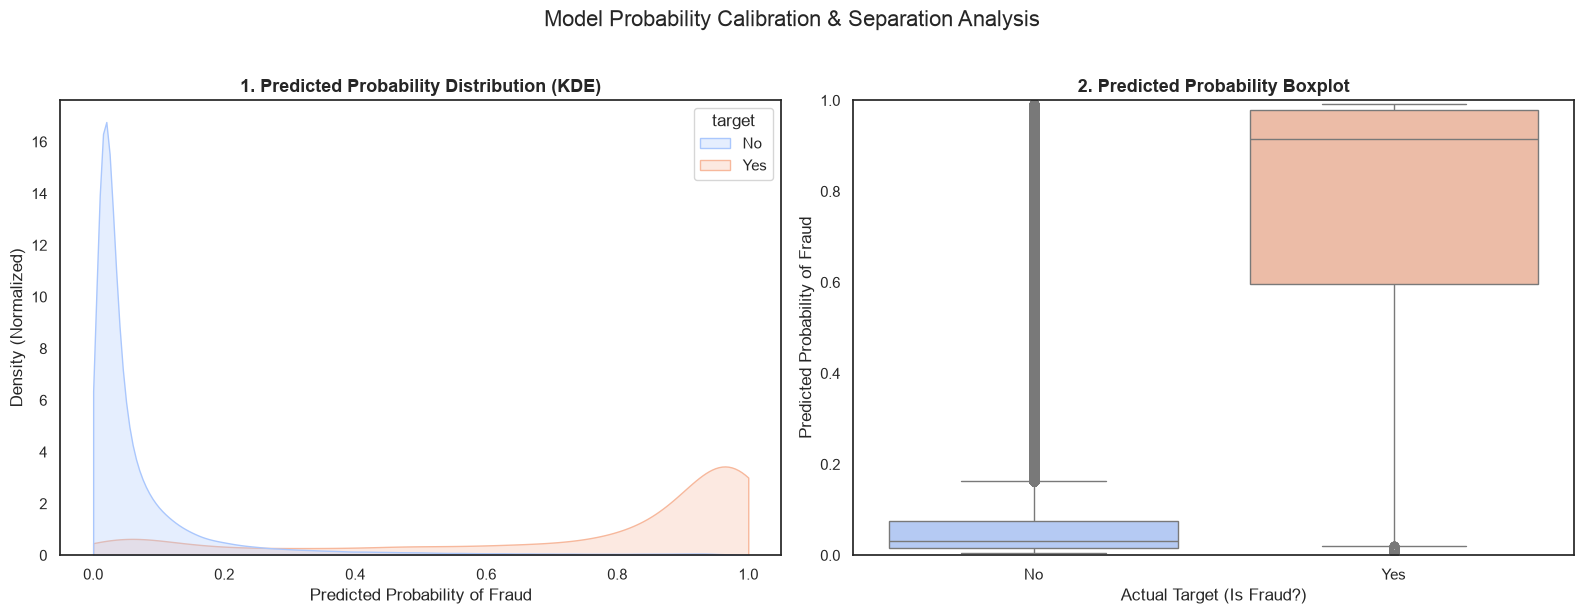

In [41]:


df_plot = df.copy()
if df_plot["target"].dtype != "object":
    df_plot["target"] = df_plot["target"].map({1: "Yes", 0: "No"})
else:
    df_plot["target"] = df_plot["target"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.kdeplot(
    data=df_plot,
    x="predicted_prob",
    hue="target",
    fill=True,
    alpha=0.3,
    palette="coolwarm",
    common_norm=False, 
    clip=(0, 1),        
    ax=axes[0]
)
axes[0].set_title("1. Predicted Probability Distribution (KDE)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Predicted Probability of Fraud")
axes[0].set_ylabel("Density (Normalized)")

sns.boxplot(
    data=df_plot,
    x="target",
    y="predicted_prob",
    palette="coolwarm",
    hue="target",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("2. Predicted Probability Boxplot", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Actual Target (Is Fraud?)")
axes[1].set_ylabel("Predicted Probability of Fraud")
axes[1].set_ylim(0, 1) 

plt.suptitle("Model Probability Calibration & Separation Analysis", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

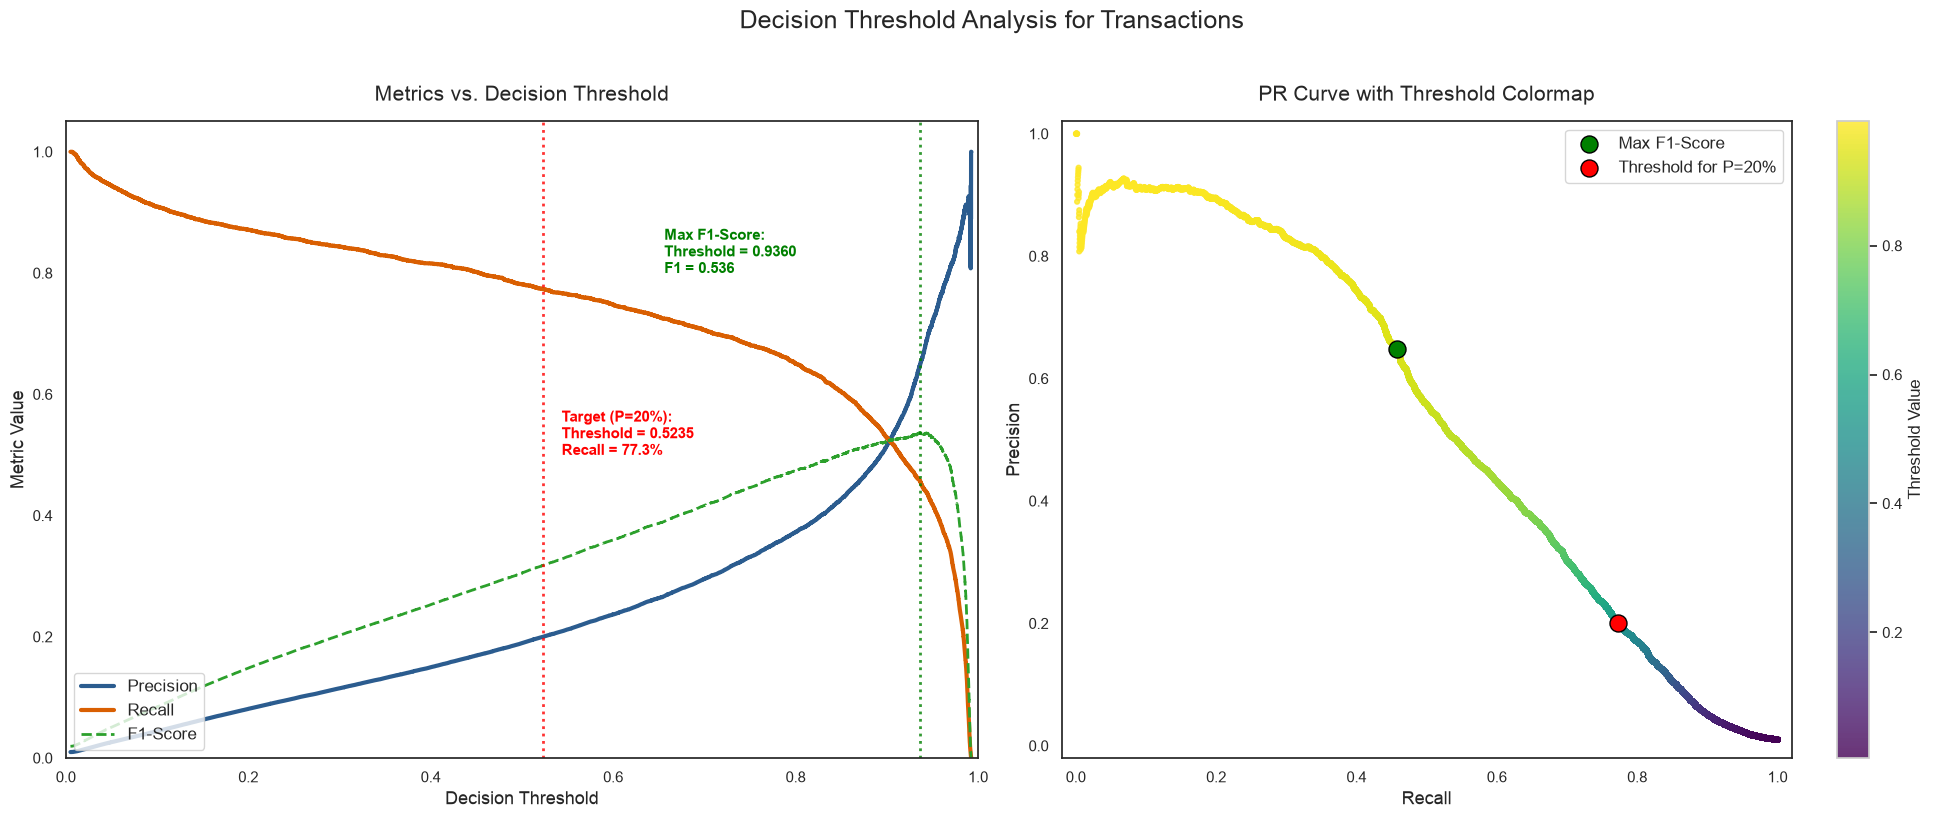

In [42]:


def plot_threshold_analysis(df):
    valid_data = df[['target', 'predicted_prob']].dropna()
    y_true = (valid_data["target"] == "Yes").astype(int)
    y_prob = valid_data["predicted_prob"]
    
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    p_curve = precisions[:-1]
    r_curve = recalls[:-1]
    f1_curve = f1_scores[:-1]
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    sns.set_theme(style="whitegrid")
    
    ax1 = axes[0]
    ax1.plot(thresholds, p_curve, label="Precision", color="#2b5c8f", lw=3)
    ax1.plot(thresholds, r_curve, label="Recall", color="#d95f02", lw=3)
    ax1.plot(thresholds, f1_curve, label="F1-Score", color="#2ca02c", lw=2, linestyle="--")
    
    best_f1_idx = np.argmax(f1_curve)
    best_thresh_f1 = thresholds[best_f1_idx]
    best_f1_val = f1_curve[best_f1_idx]
    
    target_p = 0.20
    p_target_indices = np.where(p_curve >= target_p)[0]
    if len(p_target_indices) > 0:
        thresh_p_target = thresholds[p_target_indices[0]]
        recall_p_target = r_curve[p_target_indices[0]]
        
        ax1.axvline(x=thresh_p_target, color="red", linestyle=":", alpha=0.8, lw=2)
        ax1.text(thresh_p_target + 0.02, 0.5, f"Target (P={target_p:.0%}):\nThreshold = {thresh_p_target:.4f}\nRecall = {recall_p_target:.1%}", color="red", fontsize=11, weight="bold")
        
    ax1.axvline(x=best_thresh_f1, color="green", linestyle=":", alpha=0.8, lw=2)
    ax1.text(best_thresh_f1 - 0.28, 0.8, f"Max F1-Score:\nThreshold = {best_thresh_f1:.4f}\nF1 = {best_f1_val:.3f}", color="green", fontsize=11, weight="bold")
    
    ax1.set_title("Metrics vs. Decision Threshold", fontsize=15, pad=15)
    ax1.set_xlabel("Decision Threshold", fontsize=13)
    ax1.set_ylabel("Metric Value", fontsize=13)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1.05)
    ax1.legend(fontsize=12, loc="lower left")
    
    ax2 = axes[1]
    sc = ax2.scatter(r_curve, p_curve, c=thresholds, cmap="viridis", s=12, alpha=0.8)
    
    cbar = plt.colorbar(sc, ax=ax2)
    cbar.set_label("Threshold Value", fontsize=12)
    
    ax2.scatter(recalls[:-1][best_f1_idx], precisions[:-1][best_f1_idx], color="green", s=150, edgecolors="black", zorder=5, label="Max F1-Score")
    if len(p_target_indices) > 0:
        ax2.scatter(recalls[:-1][p_target_indices[0]], precisions[:-1][p_target_indices[0]], color="red", s=150, edgecolors="black", zorder=5, label=f"Threshold for P={target_p:.0%}")
        
    ax2.set_title("PR Curve with Threshold Colormap", fontsize=15, pad=15)
    ax2.set_xlabel("Recall", fontsize=13)
    ax2.set_ylabel("Precision", fontsize=13)
    ax2.set_xlim(-0.02, 1.02)
    ax2.set_ylim(-0.02, 1.02)
    ax2.legend(fontsize=12, loc="upper right")
    
    plt.suptitle("Decision Threshold Analysis for Transactions", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()

plot_threshold_analysis(df)

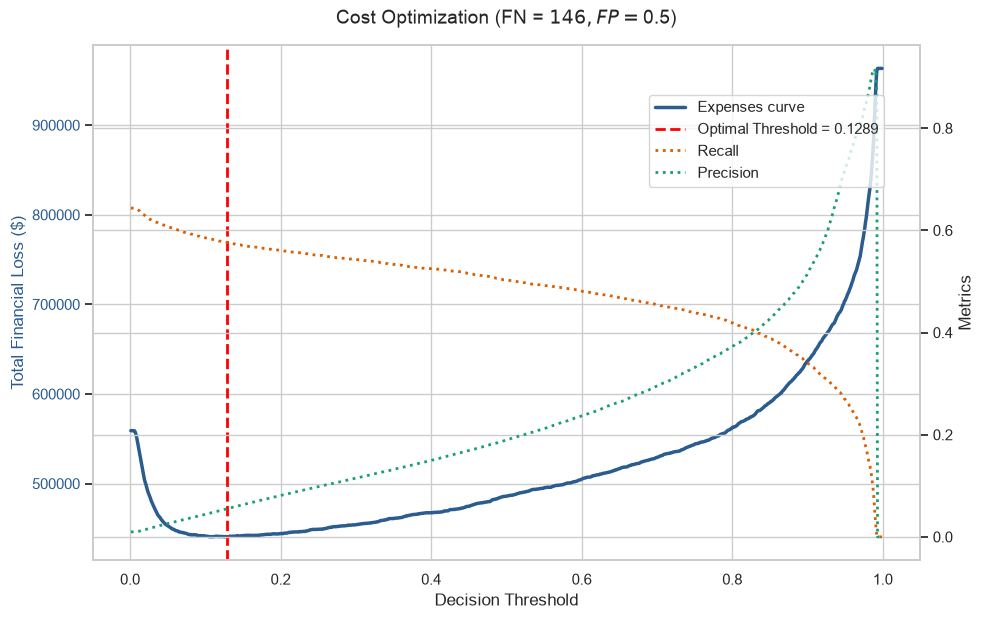

Optimal thr:  0.1289
Min loss: $440,546
Recall:  57.65%
Precision: 5.51%


In [43]:


def optimize_threshold_by_cost(y_true, y_prob, cost_fn=150, cost_fp=2):

    thresholds = np.linspace(0.001, 0.999, 1000)
    costs = []
    recalls = []
    precisions = []
    
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        cm = confusion_matrix(y_true, y_pred)
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
        else:
            fp = sum((y_true == 0) & (y_pred == 1))
            fn = sum((y_true == 1) & (y_pred == 0))
            tp = sum((y_true == 1) & (y_pred == 1))
            
        total_cost = (fp * cost_fp) + (fn * cost_fn)
        costs.append(total_cost)
        
        recalls.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        precisions.append(tp / (tp + fp) if (tp + fp) > 0 else 0)
        
    best_idx = np.argmin(costs)
    best_threshold = thresholds[best_idx]
    min_cost = costs[best_idx]
    
    sns.set_theme(style="whitegrid")
    fig, ax1 = plt.subplots(figsize=(10, 6))

    color = '#2b5c8f'
    ax1.set_xlabel('Decision Threshold', fontsize=12)
    ax1.set_ylabel('Total Financial Loss ($)', color=color, fontsize=12)
    ax1.plot(thresholds, costs, color=color, lw=2.5, label='Expenses curve')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.axvline(best_threshold, color='red', linestyle='--', lw=2, 
                label=f'Optimal Threshold = {best_threshold:.4f}')

    ax2 = ax1.twinx()  
    color_rec = '#d95f02'
    color_prec = '#1b9e77'
    ax2.set_ylabel('Metrics', fontsize=12)  
    ax2.plot(thresholds, recalls, color=color_rec, linestyle=':', lw=2, label='Recall')
    ax2.plot(thresholds, precisions, color=color_prec, linestyle=':', lw=2, label='Precision')
    
    fig.tight_layout()
    fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
    plt.title(f'Cost Optimization (FN = ${cost_fn}, FP = ${cost_fp})', fontsize=14, pad=15)
    plt.show()
    
    print(f"Optimal thr:  {best_threshold:.4f}")
    print(f"Min loss: ${min_cost:,.0f}")
    print(f"Recall:  {recalls[best_idx]:.2%}")
    print(f"Precision: {precisions[best_idx]:.2%}")
    
    return best_threshold

best_t = optimize_threshold_by_cost((df['target']=='Yes').astype(int),df['predicted_prob'],cost_fn=146, cost_fp=0.5)



In [46]:
def cost_sensitivity(y_true, y_prob, cost_fn, cost_fp_values):
    thresholds = np.linspace(0.001, 0.999, 500)
    rows = []

    for cost_fp in cost_fp_values:
        best_cost = None
        for t in thresholds:
            y_pred = (y_prob >= t).astype(int)
            fp = ((y_true == 0) & (y_pred == 1)).sum()
            fn = ((y_true == 1) & (y_pred == 0)).sum()
            tp = ((y_true == 1) & (y_pred == 1)).sum()
            cost = fp * cost_fp + fn * cost_fn
            if best_cost is None or cost < best_cost:
                best_cost = cost
                best_t = t
                best_tp, best_fp, best_fn = tp, fp, fn

        recall = best_tp / (best_tp + best_fn) if (best_tp + best_fn) > 0 else 0
        precision = best_tp / (best_tp + best_fp) if (best_tp + best_fp) > 0 else 0
        rows.append({"cost_fp": cost_fp, "threshold": best_t, "recall": recall, "precision": precision, "loss": best_cost})

    return pd.DataFrame(rows)


y_true = (df["target"] == "Yes").astype(int)
sensitivity_df = cost_sensitivity(y_true, df["predicted_prob"], cost_fn=146.4, cost_fp_values=[0.5,2, 5, 10, 20, 50])
sensitivity_df

,cost_fp,threshold,recall,precision,loss
0,0.5,0.129,0.576538,0.055158,441622.6
1,2.0,0.319,0.540164,0.121386,495771.6
2,5.0,0.573,0.488330,0.223890,550091.4
3,10.0,0.731,0.446347,0.318000,597959.2
4,20.0,0.791,0.424523,0.364666,653480.8
5,50.0,0.937,0.292816,0.653144,734402.4


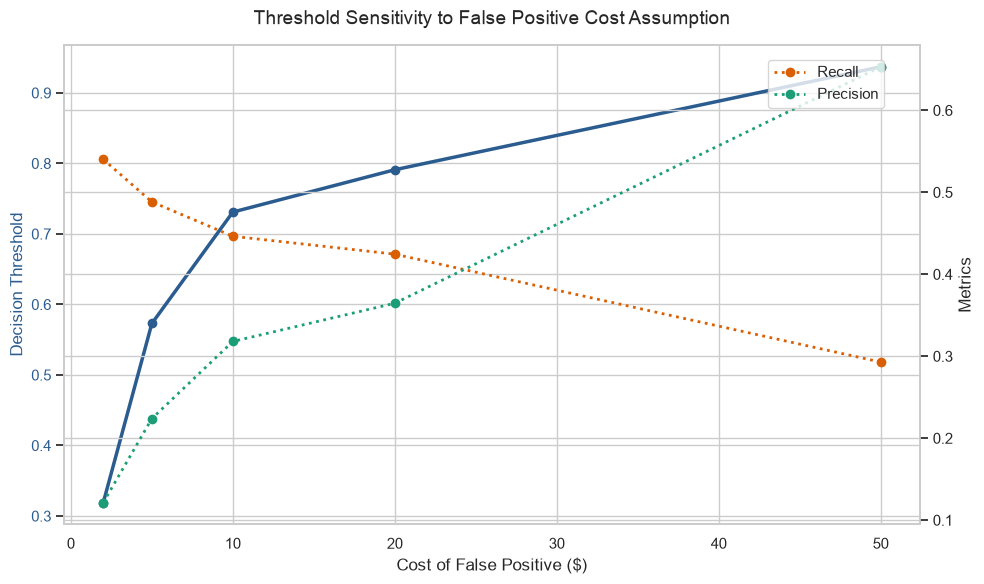

In [45]:
fig, ax1 = plt.subplots(figsize=(10, 6))

color = '#2b5c8f'
ax1.set_xlabel('Cost of False Positive ($)', fontsize=12)
ax1.set_ylabel('Decision Threshold', color=color, fontsize=12)
ax1.plot(sensitivity_df['cost_fp'], sensitivity_df['threshold'], color=color, marker='o', lw=2.5)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color_rec = '#d95f02'
color_prec = '#1b9e77'
ax2.set_ylabel('Metrics', fontsize=12)
ax2.plot(sensitivity_df['cost_fp'], sensitivity_df['recall'], color=color_rec, marker='o', linestyle=':', lw=2, label='Recall')
ax2.plot(sensitivity_df['cost_fp'], sensitivity_df['precision'], color=color_prec, marker='o', linestyle=':', lw=2, label='Precision')

fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.title('Threshold Sensitivity to False Positive Cost Assumption', fontsize=14, pad=15)
plt.tight_layout()
plt.show()